# 1. Introduction
## Credit Risk Modeling and Default Prediction

This project analyzes borrower-level financial data to identify key drivers of credit default risk and evaluate the performance of predictive models.

The goal is to understand which borrower characteristics are most associated with default and to assess how effectively machine learning models can identify high-risk applicants.

This analysis is motivated by real-world lending decisions, where accurately assessing borrower risk is critical to minimizing financial losses.

# 2. Data Overview

In [56]:
import pandas as pd

df = pd.read_csv("../data/cs-training.csv")
df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [59]:
df.shape

(150000, 12)

In [60]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

The dataset contains 150,000 observations and multiple variables related to borrower financial behavior and credit history.


In [61]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

The target variable, `SeriousDlqin2yrs`, indicates whether a borrower experienced serious delinquency within two years.

The default rate is approximately 6–7%, indicating a highly imbalanced dataset typical of credit risk modeling.

# 3. Exploratory Data Analysis (RAW DATA)

## Missing Values

In [62]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Missing values are present in MonthlyIncome and NumberOfDependents, which will require careful handling during preprocessing.

## Age vs Default

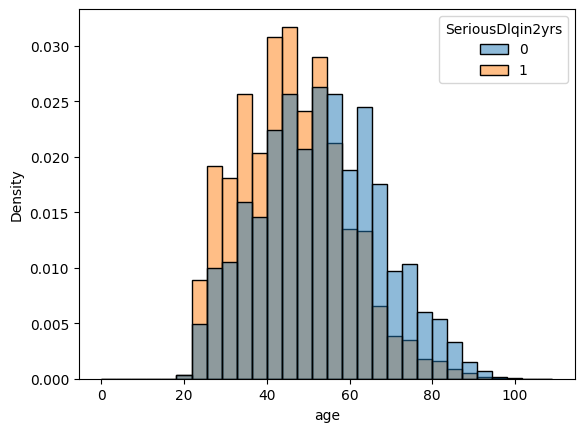

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='age', hue='SeriousDlqin2yrs', bins=30, stat='density', common_norm=False)
plt.show()

The distribution of borrower age is approximately bell-shaped with a slight right skew, reflecting a longer tail among older individuals.

There is substantial overlap between defaulters and non-defaulters across all age groups, indicating that age alone is not a strong predictor of default risk.

However, defaulters appear to be somewhat more concentrated in younger age ranges (approximately 30–50), while non-defaulters are more evenly distributed across older age groups. This suggests that younger borrowers may exhibit slightly higher risk, though the effect is relatively weak compared to behavioral variables.

## Delinquency

In [64]:
df.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean()

SeriousDlqin2yrs
0    0.135225
1    2.091362
Name: NumberOfTimes90DaysLate, dtype: float64

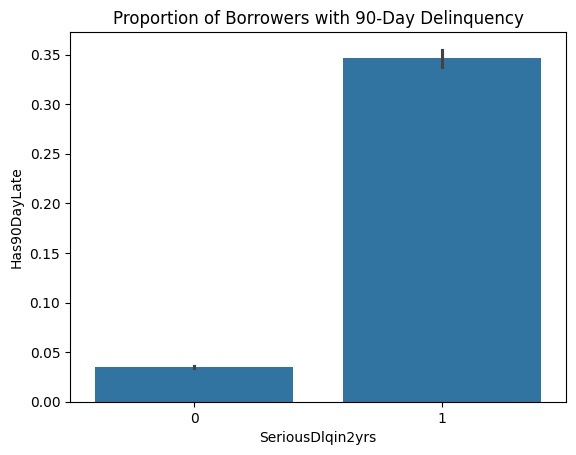

In [114]:
sns.barplot(data=df, x='SeriousDlqin2yrs', y='Has90DayLate')
plt.title("Proportion of Borrowers with 90-Day Delinquency")
plt.show()

The proportion of borrowers with a history of 90-day delinquency differs substantially between defaulters and non-defaulters.

As shown in the figure, approximately 34.6% of defaulters have experienced at least one 90-day delinquency, compared to only 3.5% of non-defaulters. This represents nearly a tenfold increase in likelihood.

Consistent with this, the average number of 90-day delinquencies is significantly higher among defaulters (2.09) than non-defaulters (0.14), indicating a large gap in repayment behavior between the two groups.

These findings highlight that past delinquency is one of the strongest predictors of future default risk, underscoring the importance of behavioral credit history in risk assessment.

## Revolving Utilization

In [112]:
df.groupby('SeriousDlqin2yrs')['RevolvingUtilization_clean'].median()

SeriousDlqin2yrs
0    0.133288
1    0.838853
Name: RevolvingUtilization_clean, dtype: float64

In [113]:
df.groupby('SeriousDlqin2yrs')['RevolvingUtilization_clean'].mean()

SeriousDlqin2yrs
0    0.297089
1    0.707025
Name: RevolvingUtilization_clean, dtype: float64

Revolving credit utilization shows a strong relationship with default risk after addressing extreme outliers.

Using the median, borrowers who default have substantially higher utilization rates (0.84) compared to non-defaulters (0.13). This represents more than a sixfold difference, indicating significantly greater reliance on credit among high-risk borrowers.

Because the distribution of utilization is highly skewed, the median provides a more robust measure of central tendency than the mean. 

These findings suggest that high credit utilization is a key indicator of financial stress and an important predictor of default risk, consistent with real-world credit scoring models.

# 4. Data Cleaning

In [ ]:
# Drop the unnecessary 'Unnamed: 0' column that was created when reading the CSV file
df = df.drop(columns=['Unnamed: 0'])

In [67]:
# Create missing indicator
df['IncomeMissing'] = df['MonthlyIncome'].isnull().astype(int)

# Fill missing values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [68]:
# Cap extreme utilization values
df['RevolvingUtilization_clean'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

# Binary delinquency indicator
df['Has90DayLate'] = (df['NumberOfTimes90DaysLate'] > 0).astype(int)

In [69]:
df = df.drop(columns=['NumberOfTimes90DaysLate'])

Data preprocessing included handling missing values, capping extreme outliers, and engineering new features to better capture borrower risk.

A binary indicator for serious delinquency was created, and redundant variables were removed to improve model interpretability.

# 5. Modeling (Logistic Regression)
Logistic regression is well-suited for this problem because it models the probability of a binary outcome (default vs. no default) while remaining highly interpretable, allowing us to understand how each feature contributes to credit risk.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# 6. Model Evaluation

In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9342
Precision: 0.4845360824742268
Recall: 0.1441717791411043
ROC AUC: 0.836799384636296


The model achieves strong overall classification performance (ROC AUC ~0.84), indicating good ability to distinguish between defaulters and non-defaulters.

However, recall is relatively low, suggesting that many defaulters are not identified at the default threshold. For this reason the threshold will be lowered.

# 7. Threshold Adjustment

In [92]:
y_pred_adjusted = (y_prob > 0.2).astype(int)

from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred_adjusted))
print("Recall:", recall_score(y_test, y_pred_adjusted))

Precision: 0.4196277495769882
Recall: 0.3803680981595092


Lowering the classification threshold significantly improves recall, allowing the model to identify a larger share of defaulters.

This comes at the cost of reduced precision, reflecting a tradeoff between identifying high-risk borrowers and avoiding false positives.

# 8. Feature Importance

In [110]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

feature_importance.sort_values(by='coefficient', ascending=False)

,feature,coefficient
2,NumberOfTime30-59DaysPastDueNotWorse,1.159900
10,RevolvingUtilization_clean,0.742992
11,Has90DayLate,0.443084
5,NumberOfOpenCreditLinesAndLoans,0.227031
6,NumberRealEstateLoansOrLines,0.107475
8,NumberOfDependents,0.053865
9,IncomeMissing,0.000000
3,DebtRatio,-0.057168
1,age,-0.266627
0,RevolvingUtilizationOfUnsecuredLines,-0.266917


The model identifies delinquency history and credit utilization as the strongest predictors of default risk.

Behavioral indicators of past repayment performance are more predictive than demographic characteristics, consistent with real-world credit scoring models.

# 9. Key Insights

- Past delinquency is the strongest predictor of default risk
- High credit utilization is associated with increased financial stress
- Behavioral variables outperform demographic variables in predicting default
- Adjusting the classification threshold significantly improves risk detection

# 10. Limitations

- The dataset is historical and may not reflect current lending conditions
- Missing macroeconomic variables (e.g., interest rates, unemployment)
- Static snapshot of borrower data rather than time-series behavior